In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
#Always inspect the first rows before doing anything else.
#This helps us understand the structure and spot obvious issues.

df = pd.read_csv("goodreads_books.csv")
df.head()

,bookId,title,series,author,rating,description,language,isbn,genres,characters,...,firstPublishDate,awards,numRatings,ratingsByStars,likedPercent,setting,coverImg,bbeScore,bbeVotes,price
0,2767052-the-hunger-games,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,English,9780439023481,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...","['Katniss Everdeen', 'Peeta Mellark', 'Cato (H...",...,NaN,['Locus Award Nominee for Best Young Adult Boo...,6376780,"['3444695', '1921313', '745221', '171994', '93...",96.0,"['District 12, Panem', 'Capitol, Panem', 'Pane...",https://i.gr-assets.com/images/S/compressed.ph...,2993816,30516,5.09
1,2.Harry_Potter_and_the_Order_of_the_Phoenix,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,There is a door at the end of a silent corrido...,English,9780439358071,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","['Sirius Black', 'Draco Malfoy', 'Ron Weasley'...",...,06/21/03,['Bram Stoker Award for Works for Young Reader...,2507623,"['1593642', '637516', '222366', '39573', '14526']",98.0,['Hogwarts School of Witchcraft and Wizardry (...,https://i.gr-assets.com/images/S/compressed.ph...,2632233,26923,7.38
2,2657.To_Kill_a_Mockingbird,To Kill a Mockingbird,To Kill a Mockingbird,Harper Lee,4.28,The unforgettable novel of a childhood in a sl...,English,9999999999999,"['Classics', 'Fiction', 'Historical Fiction', ...","['Scout Finch', 'Atticus Finch', 'Jem Finch', ...",...,07/11/60,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,"['2363896', '1333153', '573280', '149952', '80...",95.0,"['Maycomb, Alabama (United States)']",https://i.gr-assets.com/images/S/compressed.ph...,2269402,23328,NaN
3,1885.Pride_and_Prejudice,Pride and Prejudice,NaN,"Jane Austen, Anna Quindlen (Introduction)",4.26,Alternate cover edition of ISBN 9780679783268S...,English,9999999999999,"['Classics', 'Fiction', 'Romance', 'Historical...","['Mr. Bennet', 'Mrs. Bennet', 'Jane Bennet', '...",...,01/28/13,[],2998241,"['1617567', '816659', '373311', '113934', '767...",94.0,"['United Kingdom', 'Derbyshire, England (Unite...",https://i.gr-assets.com/images/S/compressed.ph...,1983116,20452,NaN
4,41865.Twilight,Twilight,The Twilight Saga #1,Stephenie Meyer,3.60,About three things I was absolutely positive.\...,English,9780316015844,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...","['Edward Cullen', 'Jacob Black', 'Laurent', 'R...",...,10/05/05,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,"['1751460', '1113682', '1008686', '542017', '5...",78.0,"['Forks, Washington (United States)', 'Phoenix...",https://i.gr-assets.com/images/S/compressed.ph...,1459448,14874,2.1


In [5]:
#Inspect the dataset
print(df.info())
print(df.isna().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52478 entries, 0 to 52477
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bookId            52478 non-null  object 
 1   title             52478 non-null  object 
 2   series            23470 non-null  object 
 3   author            52478 non-null  object 
 4   rating            52478 non-null  float64
 5   description       51140 non-null  object 
 6   language          48672 non-null  object 
 7   isbn              52478 non-null  object 
 8   genres            52478 non-null  object 
 9   characters        52478 non-null  object 
 10  bookFormat        51005 non-null  object 
 11  edition           4955 non-null   object 
 12  pages             50131 non-null  object 
 13  publisher         48782 non-null  object 
 14  publishDate       51598 non-null  object 
 15  firstPublishDate  31152 non-null  object 
 16  awards            52478 non-null  object

In [13]:
df=df[:5000]
df.head()

,bookId,title,series,author,rating,description,language,isbn,genres,characters,...,firstPublishDate,awards,numRatings,ratingsByStars,likedPercent,setting,coverImg,bbeScore,bbeVotes,price
0,2767052-the-hunger-games,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,English,9780439023481,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...","['Katniss Everdeen', 'Peeta Mellark', 'Cato (H...",...,NaN,['Locus Award Nominee for Best Young Adult Boo...,6376780,"['3444695', '1921313', '745221', '171994', '93...",96.0,"['District 12, Panem', 'Capitol, Panem', 'Pane...",https://i.gr-assets.com/images/S/compressed.ph...,2993816,30516,5.09
1,2.Harry_Potter_and_the_Order_of_the_Phoenix,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,There is a door at the end of a silent corrido...,English,9780439358071,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","['Sirius Black', 'Draco Malfoy', 'Ron Weasley'...",...,06/21/03,['Bram Stoker Award for Works for Young Reader...,2507623,"['1593642', '637516', '222366', '39573', '14526']",98.0,['Hogwarts School of Witchcraft and Wizardry (...,https://i.gr-assets.com/images/S/compressed.ph...,2632233,26923,7.38
2,2657.To_Kill_a_Mockingbird,To Kill a Mockingbird,To Kill a Mockingbird,Harper Lee,4.28,The unforgettable novel of a childhood in a sl...,English,9999999999999,"['Classics', 'Fiction', 'Historical Fiction', ...","['Scout Finch', 'Atticus Finch', 'Jem Finch', ...",...,07/11/60,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,"['2363896', '1333153', '573280', '149952', '80...",95.0,"['Maycomb, Alabama (United States)']",https://i.gr-assets.com/images/S/compressed.ph...,2269402,23328,NaN
3,1885.Pride_and_Prejudice,Pride and Prejudice,NaN,"Jane Austen, Anna Quindlen (Introduction)",4.26,Alternate cover edition of ISBN 9780679783268S...,English,9999999999999,"['Classics', 'Fiction', 'Romance', 'Historical...","['Mr. Bennet', 'Mrs. Bennet', 'Jane Bennet', '...",...,01/28/13,[],2998241,"['1617567', '816659', '373311', '113934', '767...",94.0,"['United Kingdom', 'Derbyshire, England (Unite...",https://i.gr-assets.com/images/S/compressed.ph...,1983116,20452,NaN
4,41865.Twilight,Twilight,The Twilight Saga #1,Stephenie Meyer,3.60,About three things I was absolutely positive.\...,English,9780316015844,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...","['Edward Cullen', 'Jacob Black', 'Laurent', 'R...",...,10/05/05,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,"['1751460', '1113682', '1008686', '542017', '5...",78.0,"['Forks, Washington (United States)', 'Phoenix...",https://i.gr-assets.com/images/S/compressed.ph...,1459448,14874,2.1


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bookId            1000 non-null   object 
 1   title             1000 non-null   object 
 2   series            474 non-null    object 
 3   author            1000 non-null   object 
 4   rating            1000 non-null   float64
 5   description       993 non-null    object 
 6   language          990 non-null    object 
 7   isbn              1000 non-null   object 
 8   genres            1000 non-null   object 
 9   characters        1000 non-null   object 
 10  bookFormat        998 non-null    object 
 11  edition           271 non-null    object 
 12  pages             999 non-null    object 
 13  publisher         989 non-null    object 
 14  publishDate       998 non-null    object 
 15  firstPublishDate  753 non-null    object 
 16  awards            1000 non-null   object 
 

In [15]:
'''This is very standard data preparation:

turn numbers into numeric values
turn dates into date objects
extract years for timeline charts
remove impossible values
'''

# Make a copy so we work safely
books = df.copy()

# Convert numeric columns
numeric_cols = ["rating", "pages", "numRatings", "likedPercent", "bbeScore", "bbeVotes", "price"]

for col in numeric_cols:
    books[col] = pd.to_numeric(books[col], errors="coerce")

# Convert date columns
books["publishDate"] = pd.to_datetime(books["publishDate"], errors="coerce")
books["firstPublishDate"] = pd.to_datetime(books["firstPublishDate"], errors="coerce")

# Extract publication years
books["publishYear"] = books["publishDate"].dt.year
books["firstPublishYear"] = books["firstPublishDate"].dt.year

# Clean obvious impossible values
books = books[books["pages"].isna() | (books["pages"] > 0)]
books = books[books["numRatings"].isna() | (books["numRatings"] >= 0)]
books = books[books["rating"].isna() | ((books["rating"] >= 0) & (books["rating"] <= 5))]

/tmp/ipykernel_1194/429685140.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  books["publishDate"] = pd.to_datetime(books["publishDate"], errors="coerce")
/tmp/ipykernel_1194/429685140.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  books["firstPublishDate"] = pd.to_datetime(books["firstPublishDate"], errors="coerce")


In [16]:
books.head()

,bookId,title,series,author,rating,description,language,isbn,genres,characters,...,numRatings,ratingsByStars,likedPercent,setting,coverImg,bbeScore,bbeVotes,price,publishYear,firstPublishYear
0,2767052-the-hunger-games,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,English,9780439023481,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...","['Katniss Everdeen', 'Peeta Mellark', 'Cato (H...",...,6376780,"['3444695', '1921313', '745221', '171994', '93...",96.0,"['District 12, Panem', 'Capitol, Panem', 'Pane...",https://i.gr-assets.com/images/S/compressed.ph...,2993816,30516,5.09,2008.0,NaN
1,2.Harry_Potter_and_the_Order_of_the_Phoenix,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,There is a door at the end of a silent corrido...,English,9780439358071,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","['Sirius Black', 'Draco Malfoy', 'Ron Weasley'...",...,2507623,"['1593642', '637516', '222366', '39573', '14526']",98.0,['Hogwarts School of Witchcraft and Wizardry (...,https://i.gr-assets.com/images/S/compressed.ph...,2632233,26923,7.38,2004.0,2003.0
2,2657.To_Kill_a_Mockingbird,To Kill a Mockingbird,To Kill a Mockingbird,Harper Lee,4.28,The unforgettable novel of a childhood in a sl...,English,9999999999999,"['Classics', 'Fiction', 'Historical Fiction', ...","['Scout Finch', 'Atticus Finch', 'Jem Finch', ...",...,4501075,"['2363896', '1333153', '573280', '149952', '80...",95.0,"['Maycomb, Alabama (United States)']",https://i.gr-assets.com/images/S/compressed.ph...,2269402,23328,NaN,2006.0,2060.0
3,1885.Pride_and_Prejudice,Pride and Prejudice,NaN,"Jane Austen, Anna Quindlen (Introduction)",4.26,Alternate cover edition of ISBN 9780679783268S...,English,9999999999999,"['Classics', 'Fiction', 'Romance', 'Historical...","['Mr. Bennet', 'Mrs. Bennet', 'Jane Bennet', '...",...,2998241,"['1617567', '816659', '373311', '113934', '767...",94.0,"['United Kingdom', 'Derbyshire, England (Unite...",https://i.gr-assets.com/images/S/compressed.ph...,1983116,20452,NaN,2000.0,2013.0
4,41865.Twilight,Twilight,The Twilight Saga #1,Stephenie Meyer,3.60,About three things I was absolutely positive.\...,English,9780316015844,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...","['Edward Cullen', 'Jacob Black', 'Laurent', 'R...",...,4964519,"['1751460', '1113682', '1008686', '542017', '5...",78.0,"['Forks, Washington (United States)', 'Phoenix...",https://i.gr-assets.com/images/S/compressed.ph...,1459448,14874,2.10,2006.0,2005.0


/tmp/ipykernel_1194/1248362540.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=format_counts, x="bookFormat", y="count", palette="magma")


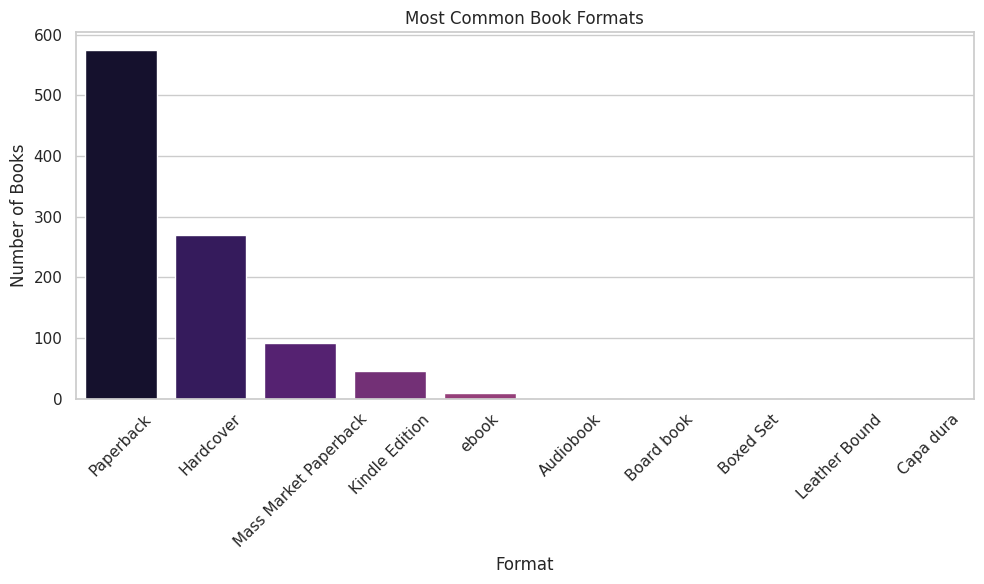

In [18]:
#format- bar chart
format_counts = books["bookFormat"].value_counts(dropna=True).head(10).reset_index()
format_counts.columns = ["bookFormat", "count"]

sns.barplot(data=format_counts, x="bookFormat", y="count", palette="magma")
plt.title("Most Common Book Formats")
plt.xlabel("Format")
plt.ylabel("Number of Books")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

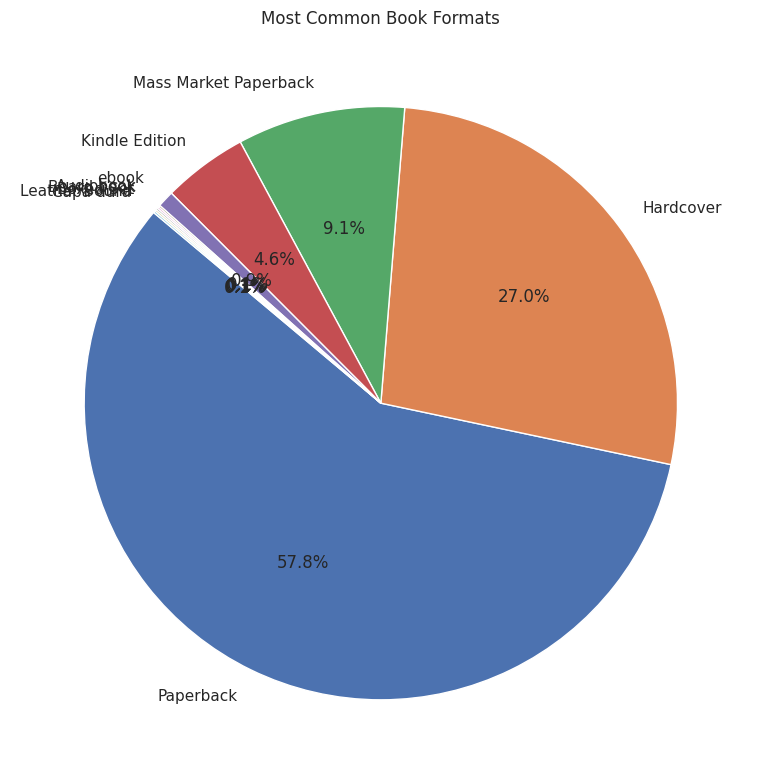

In [20]:
#format-pie chart
format_counts = books["bookFormat"].value_counts(dropna=True).head(10).reset_index()
format_counts.columns = ["bookFormat", "count"]

plt.figure(figsize=(8, 8))
plt.pie(
    format_counts["count"],
    labels=format_counts["bookFormat"],
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Most Common Book Formats")
plt.tight_layout()
plt.show()

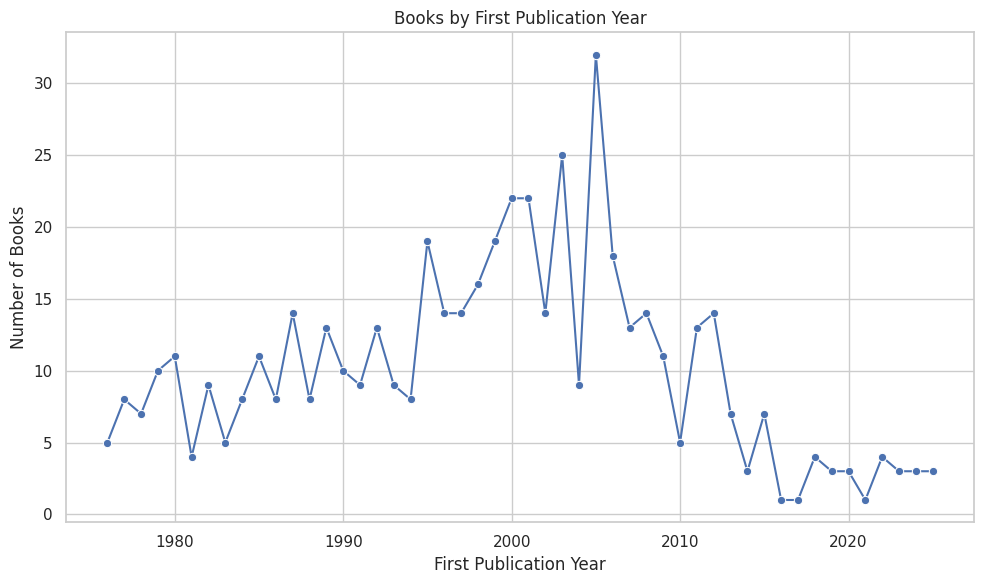

In [21]:
#TIMELINES / TIME SERIES
#Books by first publication year
year_counts = books["firstPublishYear"].value_counts(dropna=True).sort_index().reset_index()
year_counts.columns = ["firstPublishYear", "count"]

# Optional: keep a sensible range
year_counts = year_counts[(year_counts["firstPublishYear"] >= 1800) & (year_counts["firstPublishYear"] <= 2025)]

sns.lineplot(data=year_counts, x="firstPublishYear", y="count", marker="o")
plt.title("Books by First Publication Year")
plt.xlabel("First Publication Year")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

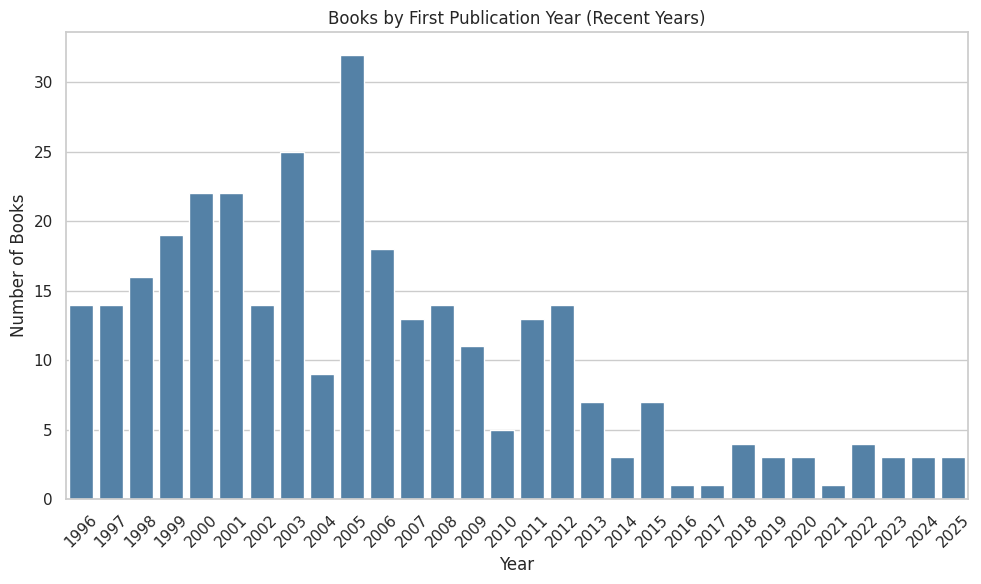

In [23]:
#Bar chart over time
sns.barplot(data=year_counts.tail(30), x="firstPublishYear", y="count", color="steelblue")
plt.title("Books by First Publication Year (Recent Years)")
plt.xlabel("Year")
plt.ylabel("Number of Books")
plt.xticks(
    ticks=range(len(year_counts.tail(30))),
    labels=year_counts.tail(30)["firstPublishYear"].astype(int),
    rotation=45
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1194/1814062034.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=publisher_counts, x="count", y="publisher", palette="cubehelix")


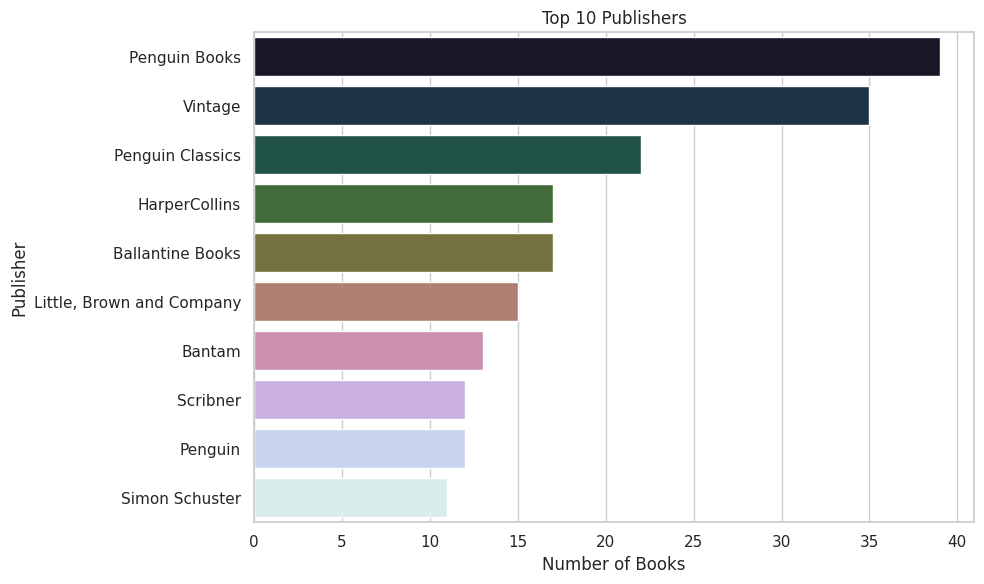

In [24]:
#Horizontal bars are often better when category names are long.
publisher_counts = books["publisher"].value_counts(dropna=True).head(10).reset_index()
publisher_counts.columns = ["publisher", "count"]

sns.barplot(data=publisher_counts, x="count", y="publisher", palette="cubehelix")
plt.title("Top 10 Publishers")
plt.xlabel("Number of Books")
plt.ylabel("Publisher")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1194/2034030764.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=author_counts, x="count", y="author", palette="crest")


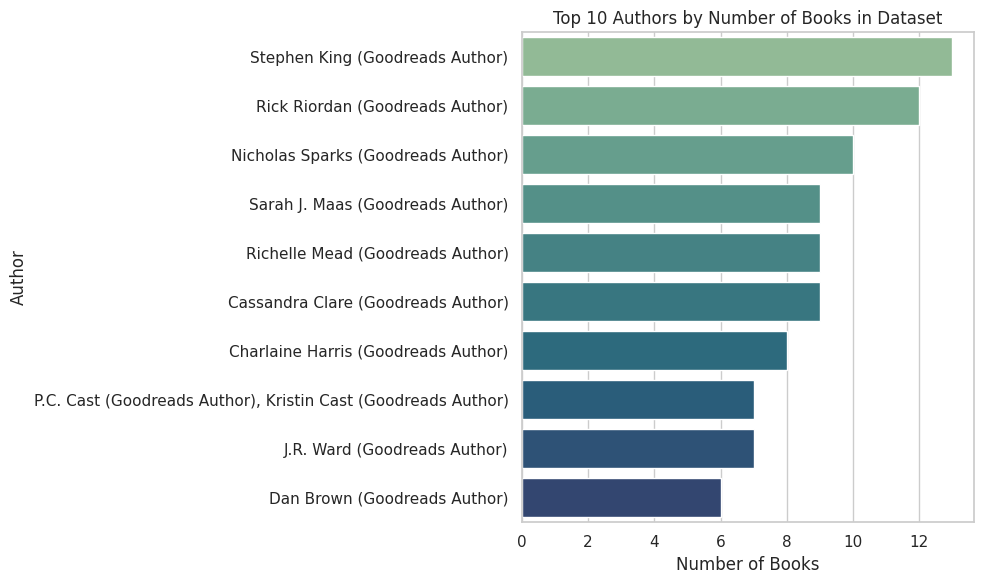

In [25]:
# top authors by count
author_counts = books["author"].value_counts(dropna=True).head(10).reset_index()
author_counts.columns = ["author", "count"]

sns.barplot(data=author_counts, x="count", y="author", palette="crest")
plt.title("Top 10 Authors by Number of Books in Dataset")
plt.xlabel("Number of Books")
plt.ylabel("Author")
plt.tight_layout()
plt.show()

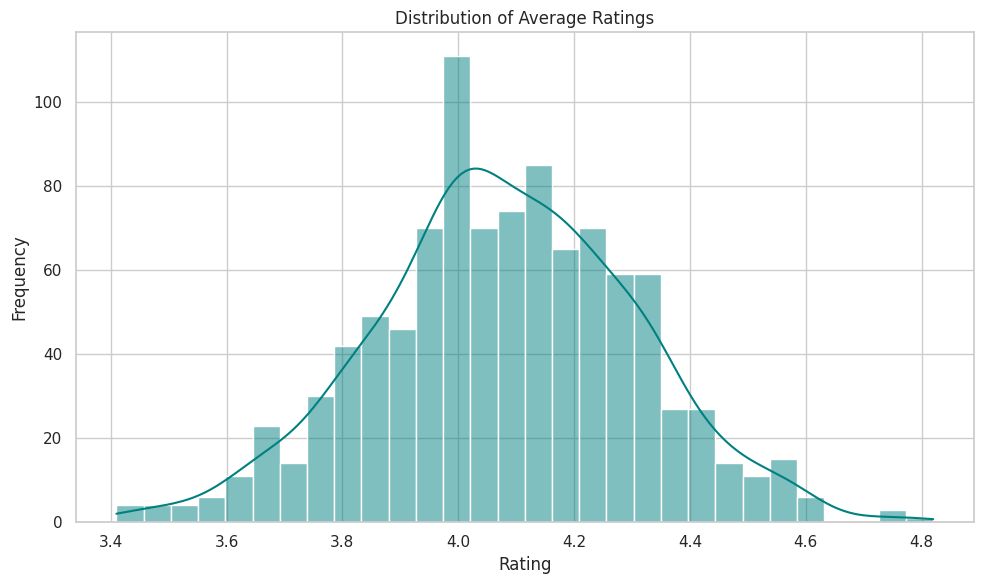

In [26]:
#rating distribution
sns.histplot(books["rating"].dropna(), bins=30, kde=True, color="teal")
plt.title("Distribution of Average Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()